In [3]:
library(tidyverse)
library(repr)
library(tidymodels)
library(cowplot)
options(repr.matrix.max.rows = 6)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

## Methods

### Data Wrangling & Cleaning
We performed a complete workflow consisting of data loading, cleaning, exploratory data analysis, modeling, and visualization. The analysis was conducted in R using the tidyverse and tidymodels packages.

We began by loading the player dataset containing demographic and behavioural variables. This dataset forms the basis of our predictive modeling. Next, to prepare the dataset for analysis, we selected only variables relevant to predicting subscription status. We removed missing values and converted categorical variables into factors, ensuring the dataset met the assumptions required for modeling.

In [5]:
players <- read_csv('players.csv')
players

players <- players |>
  mutate(
    experience = as.factor(experience),
    gender = as.factor(gender))
players_wrangled <- players |>
    rename(age = Age, hashed_email = hashedEmail) |>
    select(age, played_hours, experience, subscribe)
players_wrangled


Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


age,played_hours,experience,subscribe
<dbl>,<dbl>,<fct>,<lgl>
9,30.3,Pro,TRUE
17,3.8,Veteran,TRUE
17,0.0,Veteran,FALSE
⋮,⋮,⋮,⋮
57,0.0,Amateur,FALSE
17,2.3,Amateur,FALSE
NA,0.2,Pro,TRUE


### Summary Statistics for Exploratory Data Analysis

To understand the structure and distribution of the dataset, we computed summaries aligned with our planned analysis. These summaries helped us identify general player trends and assess relationships between predictors and subscription status.

In [23]:
players_summary <- players_wrangled |>
  summarise(mean_age = mean(age, na.rm = TRUE),
    mean_hours = mean(played_hours),
    number_of_players = n())
players_summary 

players_subscribed <- players_wrangled |>
  group_by(subscribe) |>
  summarise(
    mean_age = mean(age, na.rm = TRUE),
    mean_hours = mean(played_hours),
    n = n(), .groups = "drop")
players_subscribed


experience_subscription_summary <- players_wrangled |>
  group_by(experience) |>
  summarise(
    subscription_rate = (mean(subscribe == TRUE)*100),
    number_of_players = n(),
    .groups = "drop")

experience_subscription_summary


mean_age,mean_hours,number_of_players
<dbl>,<dbl>,<int>
21.13918,5.845918,196


subscribe,mean_age,mean_hours,n
<lgl>,<dbl>,<dbl>,<int>
FALSE,23.7500,0.5019231,52
TRUE,20.1831,7.7756944,144


experience,subscription_rate,number_of_players
<fct>,<dbl>,<int>
Amateur,71.42857,63
Beginner,77.14286,35
Pro,71.42857,14
Regular,80.55556,36
Veteran,68.75000,48


### Exploratory Visualization


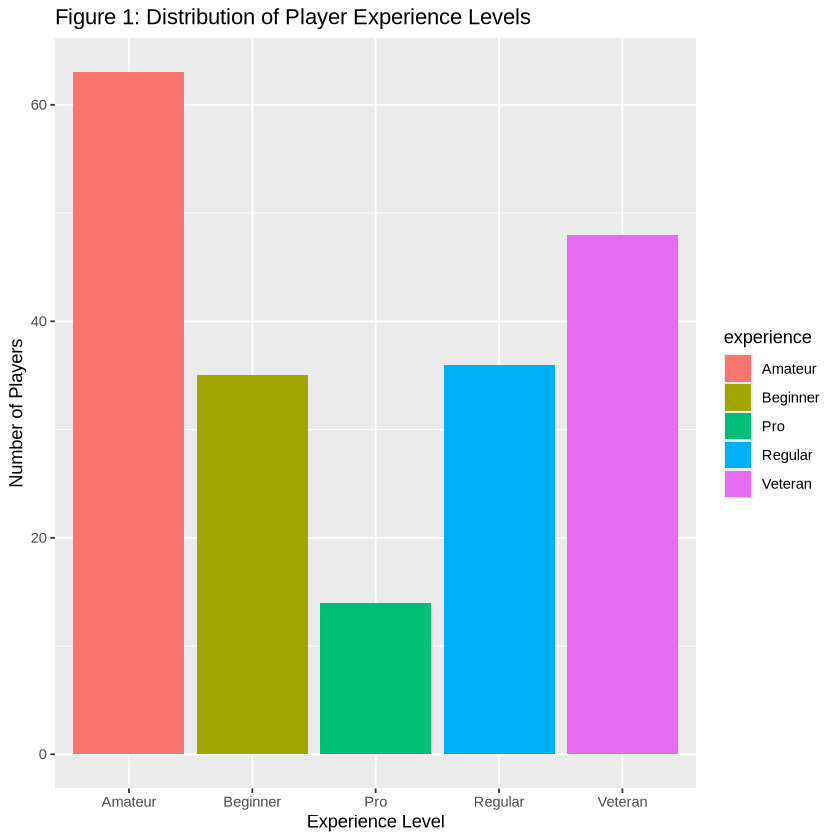

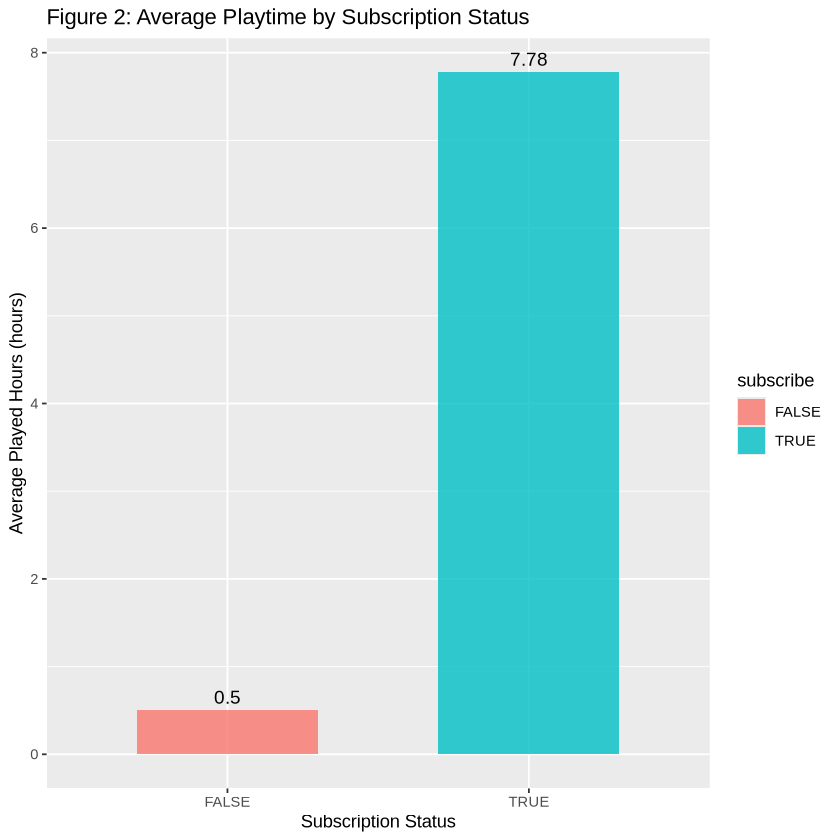

In [16]:
experience_plot <- players_wrangled |>
ggplot(aes(x = experience, fill = experience)) +
  geom_bar() +
  labs(
    title = "Figure 1: Distribution of Player Experience Levels",
    x = "Experience Level",
    y = "Number of Players"
  )
experience_plot

subscribed_summarised <- players_wrangled |>
  group_by(subscribe) |>
  summarise(mean_hours = mean(played_hours, na.rm = TRUE))

subscribed_plot <- subscribed_summarised |>  

ggplot(aes(x = subscribe, y = mean_hours, fill = subscribe)) +
  geom_col(width = 0.6, alpha = 0.8) +
  geom_text(aes(label = round(mean_hours, 2)), vjust = -0.5, size = 4) +
  labs(
    title = "Figure 2: Average Playtime by Subscription Status",
    x = "Subscription Status",
    y = "Average Played Hours (hours)"
  )
subscribed_plot